In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

df_tv = pd.read_csv("train_ind_prc.csv")
df_test = pd.read_csv("test_ind_prc.csv")
df_tv = df_tv.drop(['num__installment'], axis=1)
df_test = df_test.drop(['num__installment'], axis=1)


df_tv_exiti = df_tv.drop(['rf_rate','REAL_IRR'], axis=1)
df_test_exiti = df_test.drop(['rf_rate','REAL_IRR'], axis=1)

In [2]:
def cal_IRR(row):
    if row['pred_y'] == 1:
        return row['rf_rate']
    elif row['pred_y'] == 0:
        return row['REAL_IRR']
    else:
        return None

def cal_SR(df):
    excess_returns = df['IRR'] - df['rf_rate']
    if excess_returns.std() == 0:
        return 0
    return excess_returns.mean() / excess_returns.std()

In [3]:
# 최적 하이퍼파라미터를 찾기 위해 샘플 스플릿 with seed 0

X_tv = df_tv.drop('y', axis=1)
X_test = df_test.drop('y', axis=1)
y_tv = df_tv['y']
y_test = df_test['y']

X_train_R, X_val_R, y_train, y_val = train_test_split(X_tv, y_tv, stratify=y_tv, test_size=0.1, random_state=0)

X_train = X_train_R.drop(["rf_rate", "REAL_IRR"], axis=1) 
X_val = X_val_R.drop(["rf_rate", "REAL_IRR"], axis=1)
th = np.linspace(0.15, 0.17, 10)

import optuna

def objective(trial):
    C = trial.suggest_loguniform("C", 1e-3, 10.0)
    gamma = trial.suggest_loguniform("gamma", 1e-4, 1.0)

    model = SVC(kernel='rbf', C=C, gamma=gamma, max_iter=300, probability=True)
    model.fit(X_train, y_train)
    pred_y_proba = model.predict_proba(X_val)[:, 1]
    for t in th:
        best_sr = -np.inf
        pred_y = (pred_y_proba > t).astype(int)
        X_val_R_copy = X_val_R.copy()
        X_val_R_copy['pred_y'] = pred_y
        X_val_R_copy['IRR'] = X_val_R_copy.apply(cal_IRR, axis=1)
        sr = cal_SR(X_val_R_copy)
        if sr > best_sr:
            best_sr = sr
    return best_sr

def optuna_svc(n_trials):
    best_results = []
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial), n_trials=n_trials)
    best_sr = study.best_value
    best_params = study.best_params
    best_results.append({
            'Sharpe': best_sr, 
            'params': best_params, 
        })
    return best_results

best_results = optuna_svc(n_trials=20)

[I 2025-08-21 12:06:14,921] A new study created in memory with name: no-name-3589c741-0f5b-4eb7-9a32-36190946e5a3
[I 2025-08-21 12:10:36,344] Trial 0 finished with value: 0.08193884830926938 and parameters: {'C': 2.9018221853014854, 'gamma': 0.010394618940689606}. Best is trial 0 with value: 0.08193884830926938.
[I 2025-08-21 12:14:54,341] Trial 1 finished with value: 0.010100037589071032 and parameters: {'C': 0.0022125717908647656, 'gamma': 0.0021241288594764014}. Best is trial 0 with value: 0.08193884830926938.
[I 2025-08-21 12:19:12,094] Trial 2 finished with value: 0.004994939782268518 and parameters: {'C': 0.017316700973626444, 'gamma': 0.0015841054416287693}. Best is trial 0 with value: 0.08193884830926938.
[I 2025-08-21 12:23:30,706] Trial 3 finished with value: 0.08395435535281612 and parameters: {'C': 1.739271883587553, 'gamma': 0.032602584600405854}. Best is trial 3 with value: 0.08395435535281612.
[I 2025-08-21 12:27:48,691] Trial 4 finished with value: 0.08315836454195162 a

In [4]:
best_results

[{'Sharpe': 0.08395435535281612,
  'params': {'C': 1.739271883587553, 'gamma': 0.032602584600405854}}]

In [ ]:
from sklearn.utils import resample

def bootstrap_threshold_optimization(df_tv, n_bootstrap, n_thresholds):
    best_results = []

    for i in range(n_bootstrap):
        print(f"\n=== Bootstrap {i+1}/{n_bootstrap} ===")
        
        # Bootstrap sampling
        df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i)
        X_tv = df_boot.drop('y', axis=1)
        y_tv = df_boot['y']
        X_test_R = df_test.drop('y', axis=1)

        

        X_train = X_tv.drop(["rf_rate", "REAL_IRR"], axis=1) 
        X_test = X_test_R.drop(["rf_rate", "REAL_IRR"], axis=1)

        model = SVC(kernel='rbf', C=0.1033509707854207, gamma=0.04235934843279897, max_iter=1000, probability=True)
        model.fit(X_train, y_tv)
        pred_y_proba = model.predict_proba(X_test)[:, 1]


        # Search for best threshold only (constrain to [0, 1] range)
        thresholds = np.linspace(0.01, 0.99, n_thresholds)
        best_sr = -np.inf
        best_th = 0.5
        
        for th in thresholds:
            pred_y = (pred_y_proba > th).astype(int)
            X_test_copy = X_test_R.copy()
            X_test_copy['pred_y'] = pred_y
            X_test_copy['IRR'] = X_test_copy.apply(cal_IRR, axis=1)
            sr = cal_SR(X_test_copy)
            if sr > best_sr:
                best_sr = sr
                best_th = th
        best_results.append({
            'Bootstrap': i+1,
            'Sharpe': best_sr, 
            'threshold': best_th
        })
        
        print(f"Bootstrap {i+1}: Best Sharpe={best_sr:.4f}, Threshold={best_th:.3f}")

    return best_results

print("Running bootstrap threshold optimization with fixed hyperparameters...")
best_results = bootstrap_threshold_optimization(df_tv, n_bootstrap=30, n_thresholds=20)

# Display results
results_df = pd.DataFrame(best_results)
print("\n=== Final Results ===")
print(results_df[['Bootstrap', 'Sharpe', 'threshold']])
print(f"\nMean Sharpe: {results_df['Sharpe'].mean():.4f}")
print(f"Mean Threshold: {results_df['threshold'].mean():.4f}")
print(f"Std Sharpe: {results_df['Sharpe'].std():.4f}")
print(f"Best Sharpe: {results_df['Sharpe'].max():.4f}")

# Plot results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of Sharpe ratios
ax1.hist(results_df['Sharpe'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(results_df['Sharpe'].mean(), color='red', linestyle='--', 
           label=f'Mean: {results_df["Sharpe"].mean():.4f}')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Bootstrap Sharpe Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of thresholds
ax2.hist(results_df['threshold'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(results_df['threshold'].mean(), color='red', linestyle='--',
           label=f'Mean: {results_df["threshold"].mean():.3f}')
ax2.set_xlabel('Optimal Threshold')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Optimal Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Running bootstrap threshold optimization with fixed hyperparameters...

=== Bootstrap 1/30 ===
Bootstrap 1: Best Sharpe=0.0814, Threshold=0.216

=== Bootstrap 2/30 ===
Bootstrap 2: Best Sharpe=0.0814, Threshold=0.216

=== Bootstrap 3/30 ===
Bootstrap 3: Best Sharpe=0.0813, Threshold=0.268

=== Bootstrap 4/30 ===
Bootstrap 4: Best Sharpe=0.0814, Threshold=0.216

=== Bootstrap 5/30 ===
Bootstrap 5: Best Sharpe=0.0813, Threshold=0.423

=== Bootstrap 6/30 ===
Bootstrap 6: Best Sharpe=0.0824, Threshold=0.216

=== Bootstrap 7/30 ===
Bootstrap 7: Best Sharpe=0.0813, Threshold=0.526

=== Bootstrap 8/30 ===
Bootstrap 8: Best Sharpe=0.0817, Threshold=0.216

=== Bootstrap 9/30 ===
Bootstrap 9: Best Sharpe=0.0814, Threshold=0.216

=== Bootstrap 10/30 ===
Bootstrap 10: Best Sharpe=0.0830, Threshold=0.216

=== Bootstrap 11/30 ===
Bootstrap 11: Best Sharpe=0.0815, Threshold=0.216

=== Bootstrap 12/30 ===
Bootstrap 12: Best Sharpe=0.0819, Threshold=0.165

=== Bootstrap 13/30 ===
Bootstrap 13: Best Sha

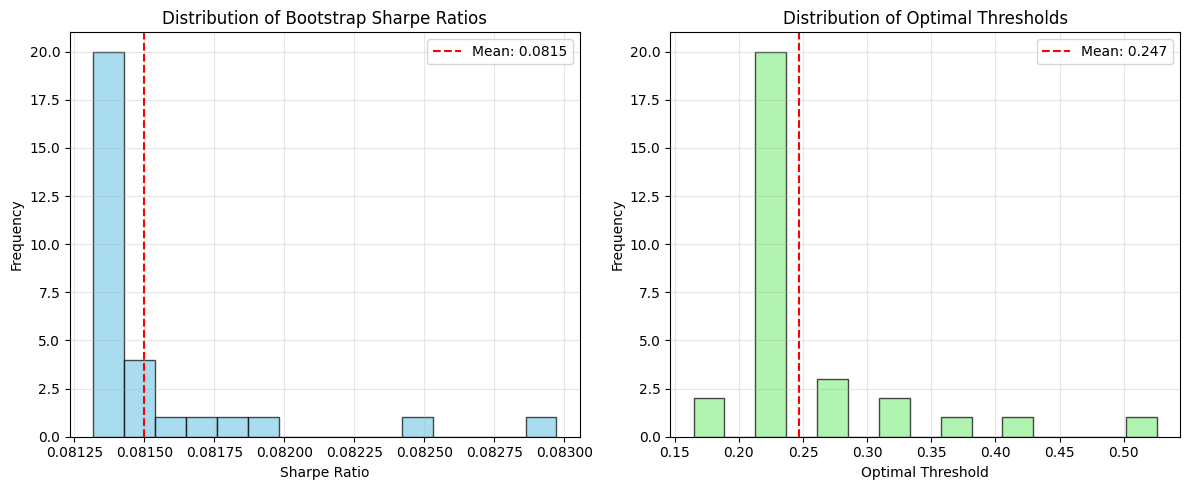

In [5]:
from sklearn.utils import resample

def bootstrap_threshold_optimization(df_tv, n_bootstrap, n_thresholds):
    best_results = []

    for i in range(n_bootstrap):
        print(f"\n=== Bootstrap {i+1}/{n_bootstrap} ===")
        
        # Bootstrap sampling
        df_boot = resample(df_tv, replace=True, n_samples=len(df_tv), random_state=i)
        X_tv = df_boot.drop('y', axis=1)
        y_tv = df_boot['y']
        X_test_R = df_test.drop('y', axis=1)

        

        X_train = X_tv.drop(["rf_rate", "REAL_IRR"], axis=1) 
        X_test = X_test_R.drop(["rf_rate", "REAL_IRR"], axis=1)

        model = SVC(kernel='rbf', C=1.739271883587553, gamma=0.032602584600405854, max_iter=1000, probability=True)
        model.fit(X_train, y_tv)
        pred_y_proba = model.predict_proba(X_test)[:, 1]


        # Search for best threshold only (constrain to [0, 1] range)
        thresholds = np.linspace(0.01, 0.99, n_thresholds)
        best_sr = -np.inf
        best_th = 0.5
        
        for th in thresholds:
            pred_y = (pred_y_proba > th).astype(int)
            X_test_copy = X_test_R.copy()
            X_test_copy['pred_y'] = pred_y
            X_test_copy['IRR'] = X_test_copy.apply(cal_IRR, axis=1)
            sr = cal_SR(X_test_copy)
            if sr > best_sr:
                best_sr = sr
                best_th = th
        best_results.append({
            'Bootstrap': i+1,
            'Sharpe': best_sr, 
            'threshold': best_th
        })
        
        print(f"Bootstrap {i+1}: Best Sharpe={best_sr:.4f}, Threshold={best_th:.3f}")

    return best_results

print("Running bootstrap threshold optimization with fixed hyperparameters...")
best_results = bootstrap_threshold_optimization(df_tv, n_bootstrap=30, n_thresholds=20)

# Display results
results_df = pd.DataFrame(best_results)
print("\n=== Final Results ===")
print(results_df[['Bootstrap', 'Sharpe', 'threshold']])
print(f"\nMean Sharpe: {results_df['Sharpe'].mean():.4f}")
print(f"Mean Threshold: {results_df['threshold'].mean():.4f}")
print(f"Std Sharpe: {results_df['Sharpe'].std():.4f}")
print(f"Best Sharpe: {results_df['Sharpe'].max():.4f}")

# Plot results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of Sharpe ratios
ax1.hist(results_df['Sharpe'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(results_df['Sharpe'].mean(), color='red', linestyle='--', 
           label=f'Mean: {results_df["Sharpe"].mean():.4f}')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Bootstrap Sharpe Ratios')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of thresholds
ax2.hist(results_df['threshold'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.axvline(results_df['threshold'].mean(), color='red', linestyle='--',
           label=f'Mean: {results_df["threshold"].mean():.3f}')
ax2.set_xlabel('Optimal Threshold')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Optimal Thresholds')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()